<a href="https://colab.research.google.com/github/Evelyn1309/proyectos/blob/main/Sememana_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UNIVERSIDAD ESTATAL AMAZONICA



# PRACTICO EXPERIMENTAL MINERIA DE DATOS
**NOMBRE:** Evelyn Arce

**PARALELO:** A

# TEMA: Conjunto de datos de Temu (mercado en línea de EE. UU.)

**Descripción General del Dataset**

Este conjunto de datos recopila información sobre productos comercializados en la plataforma de comercio electrónico Temu (mercado de EE. UU.). Está diseñado para realizar análisis exploratorios de datos (EDA), evaluación de estrategias de precios, comportamiento de volumen de ventas y métricas de satisfacción del cliente en distintas categorías de productos.

**Objetivo del Análisis**

Examinar la relación entre los precios, el volumen de ventas y las valoraciones de los usuarios para identificar los factores clave de rendimiento de los productos y la segmentación por categorías en la plataforma.

In [4]:
# 1. Instalar kagglehub dentro de la nube de Colab
!pip install kagglehub pandas

import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 2. Obtener los datos directamente a la memoria de Colab
folder_path = kagglehub.dataset_download("polartech/temu-dataset-us-online-mareket-place")

# 3. Localizar y cargar el archivo CSV
file_name = [f for f in os.listdir(folder_path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(folder_path, file_name))



100%|██████████| 2.93M/2.93M [00:01<00:00, 2.96MB/s]

Extracting files...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95189 entries, 0 to 95188
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   leve_1_category_id    95189 non-null  int64  
 1   leve_1_category_name  95189 non-null  object 
 2   leve_2_category_id    95189 non-null  int64  
 3   leve_2_category_name  95189 non-null  object 
 4   title                 95189 non-null  object 
 5   goods_id              95189 non-null  int64  
 6   sales_info            93480 non-null  object 
 7   category_id           95189 non-null  int64  
 8   visible               95189 non-null  bool   
 9   sales_volume          93480 non-null  float64
 10  price_str             95189 non-null  int64  
 11  price                 95189 non-null  float64
 12  goods_score           81070 non-null  float64
 13  comments_num_raw      81070 non-null  object 
 14  comment_num           81070 non-null  float64
dtypes: bool(1), float64

Número de entradas (filas): 95.189

Número de columnas: 15

Datos nulos:  5 de las 15 columnas contienen datos faltantes .

In [6]:
df.describe()

,leve_1_category_id,leve_2_category_id,goods_id,category_id,sales_volume,price_str,price,goods_score,comment_num
count,95189.000000,95189.000000,9.518900e+04,95189.000000,93480.00000,95189.000000,95189.000000,81070.000000,81070.000000
mean,226.003446,637.479625,2.088645e+15,693.981962,63.93206,661.739256,6.617393,4.720442,143.975540
std,211.207717,332.853023,2.417550e+15,292.339177,411.00568,749.875073,7.498751,0.369406,322.999232
min,25.000000,26.000000,6.010995e+14,27.000000,1.00000,13.000000,0.130000,1.000000,1.000000
25%,36.000000,365.000000,6.010995e+14,431.000000,3.00000,199.000000,1.990000,4.700000,6.000000
50%,204.000000,733.000000,6.010995e+14,752.000000,10.00000,449.000000,4.490000,4.800000,30.000000
75%,352.000000,898.000000,6.017592e+15,934.000000,33.00000,939.000000,9.390000,5.000000,127.000000
max,893.000000,1143.000000,6.017592e+15,1144.000000,39011.00000,56598.000000,565.980000,5.000000,3340.000000


Analisis rapido de cualquier variable nos imaginamos una recta desde el minimo al maximo y dibujo la media

In [7]:

print("=== Diagnóstico de Calidad de Datos ===")
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100
df_calidad = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': pct_nulos.round(2)})
print("Reporte de valores nulos:")
print(df_calidad[df_calidad['Nulos'] > 0])

duplicados = df.duplicated().sum()
print(f"\nRegistros duplicados exactos: {duplicados} ({(duplicados/len(df))*100:.2f}%)\n")

=== 2. Diagnóstico de Calidad de Datos ===
Reporte de valores nulos:
                  Nulos  Porcentaje (%)
sales_info         1709            1.80
sales_volume       1709            1.80
goods_score       14119           14.83
comments_num_raw  14119           14.83
comment_num       14119           14.83

Registros duplicados exactos: 432 (0.45%)



no exite datos nulos para ninguna de las variables

In [8]:

print("=== Preprocesamiento  ===")
df_clean = df.copy()

# A. Imputación de nulos
df_clean['comment_num'] = df_clean['comment_num'].fillna(0)
df_clean['goods_score'] = df_clean['goods_score'].fillna(0)
df_clean['sales_volume'] = df_clean.groupby('leve_2_category_name')['sales_volume'].transform(
    lambda x: x.fillna(x.median())
).fillna(0)

# B. Depuración de columnas redundantes
df_clean = df_clean.drop(columns=['sales_info', 'comments_num_raw', 'price_str'], errors='ignore')

# C. Transformaciones logarítmicas (tratamiento de asimetría y outliers)
df_clean['log_price'] = np.log1p(df_clean['price'])
df_clean['log_sales'] = np.log1p(df_clean['sales_volume'])
df_clean['log_comments'] = np.log1p(df_clean['comment_num'])

# D. Variables derivadas (Feature Engineering)
df_clean['price_per_rating'] = df_clean['price'] / (df_clean['goods_score'] + 0.1)
df_clean['engagement_ratio'] = df_clean['log_comments'] / (df_clean['log_sales'] + 0.1)

print(f"Total de nulos residuales tras preprocesamiento: {df_clean.isnull().sum().sum()}\n")

=== 3. Preprocesamiento e Ingeniería de Características ===
Total de nulos residuales tras preprocesamiento: 0



=== 4. Generando Visualizaciones Exploratorias ===


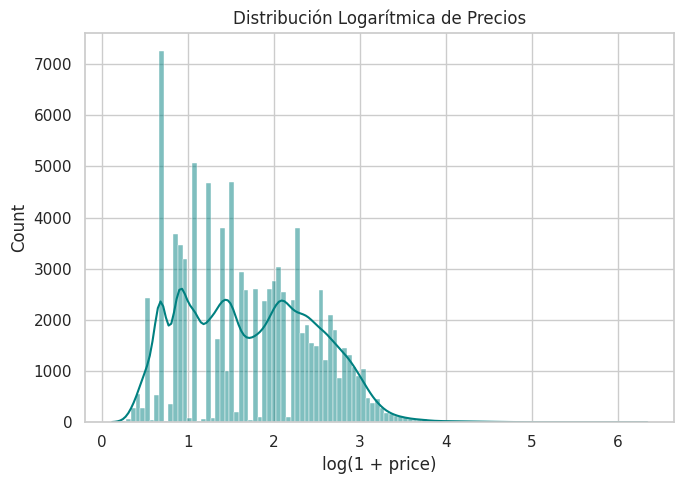

In [10]:
print("=== Generando Visualizaciones Exploratorias ===")
sns.set_theme(style="whitegrid")

# Figura de 1 solo gráfico
plt.figure(figsize=(7, 5))

# Gráfico 1: Histograma de Precios (Transformación Log)
sns.histplot(df_clean['log_price'], kde=True, color='teal')
plt.title('Distribución Logarítmica de Precios')
plt.xlabel('log(1 + price)')

plt.tight_layout()
plt.show()

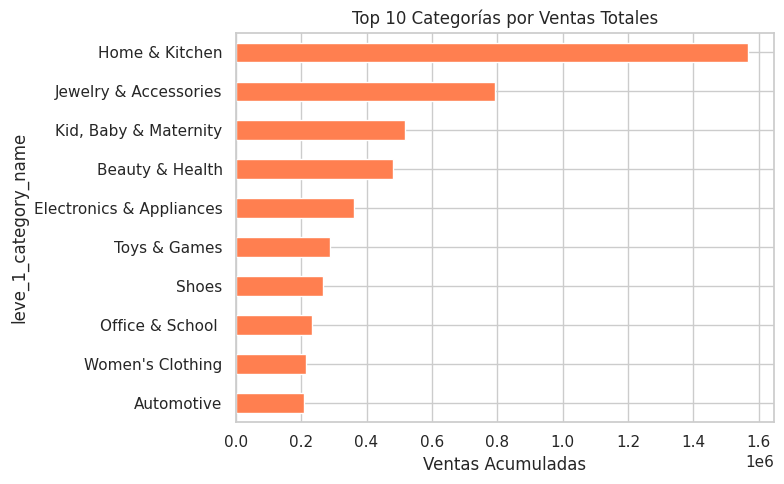

In [11]:
plt.figure(figsize=(8, 5))

top_cat = df_clean.groupby('leve_1_category_name')['sales_volume'].sum().nlargest(10)
ax = top_cat.plot(kind='barh', color='coral')

plt.title('Top 10 Categorías por Ventas Totales')
ax.invert_yaxis()
plt.xlabel('Ventas Acumuladas')

plt.tight_layout()
plt.show()

In [12]:
print("\n=== Modelado No Supervisado (K-Means) ===")
features_cluster = ['log_price', 'log_sales', 'goods_score', 'log_comments']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[features_cluster])

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['cluster'] = kmeans.fit_predict(X_scaled)

print("Centroides de los Clústeres (Valores Escalar Promedio):")
df_centroids = pd.DataFrame(kmeans.cluster_centers_, columns=features_cluster)
print(df_centroids.round(2))


=== 5. Modelado No Supervisado (K-Means) ===
Centroides de los Clústeres (Valores Escalar Promedio):
   log_price  log_sales  goods_score  log_comments
0       0.53      -0.44         0.41         -0.18
1       0.25      -0.56        -2.33         -1.45
2      -0.80       0.81         0.43          0.83


In [19]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Tomar una muestra representativa si el dataset es muy masivo (ej. 10,000 registros)
sample_mask = np.random.choice(X_scaled.shape[0], size=10000, replace=False)
sil_score = silhouette_score(X_scaled[sample_mask], df_clean['cluster'].iloc[sample_mask])
db_score = davies_bouldin_score(X_scaled, df_clean['cluster'])

print(f"Puntuación de Silueta (K=3): {sil_score:.4f}")
print(f"Índice Davies-Bouldin: {db_score:.4f}")

Puntuación de Silueta (K=3): 0.3683
Índice Davies-Bouldin: 1.0268


In [17]:
# A. Longitud del título en caracteres y palabras
df_clean['title_len_char'] = df_clean['title'].astype(str).str.len()
df_clean['title_word_count'] = df_clean['title'].astype(str).str.split().str.len()

# B. Detección de palabras clave de venta masiva
df_clean['has_pack'] = df_clean['title'].astype(str).str.contains('pack|set', case=False).astype(int)
df_clean['has_free'] = df_clean['title'].astype(str).str.contains('free', case=False).astype(int)

# Incorporar estas nuevas variables en el set X para el modelado

In [18]:
print("\n=== Entrenamiento de Modelos y Validación Cruzada ===")

X = df_clean[['log_price', 'goods_score', 'log_comments', 'price_per_rating', 'engagement_ratio', 'leve_1_category_id']]
y = df_clean['log_sales']

# División 80% Entrenamieto / 20% Prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

modelos = {
    "Regresión Lineal": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
}

resultados = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for nombre, modelo in modelos.items():
    # Entrenamiento
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    # Métricas en Hold-out (Test)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Validación Cruzada (5-Fold CV) sobre R2
    cv_scores = cross_val_score(modelo, X, y, cv=kf, scoring='r2')

    resultados.append({
        "Modelo": nombre,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 (Test 20%)": round(r2, 4),
        "R2 Promedio (5-Fold CV)": round(cv_scores.mean(), 4)
    })

df_resultados = pd.DataFrame(resultados)
print("\n--- Tabla Comparativa de Resultados ---")
print(df_resultados.to_string(index=False))


=== 6. Entrenamiento de Modelos y Validación Cruzada ===

--- Tabla Comparativa de Resultados ---
          Modelo    MAE   RMSE  R2 (Test 20%)  R2 Promedio (5-Fold CV)
Regresión Lineal 0.6514 0.8375         0.6650                   0.6669
   Random Forest 0.1152 0.3596         0.9382                   0.9401
         XGBoost 0.1355 0.3598         0.9382                   0.9394


In [20]:
from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.1],
    'subsample': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid_xgb,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)
print(f"Mejores Hiperparámetros XGBoost: {grid_xgb.best_params_}")
print(f"Mejor R2 en Validación Cruzada: {grid_xgb.best_score_:.4f}")

Mejores Hiperparámetros XGBoost: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 100, 'subsample': 1.0}
Mejor R2 en Validación Cruzada: 0.9402


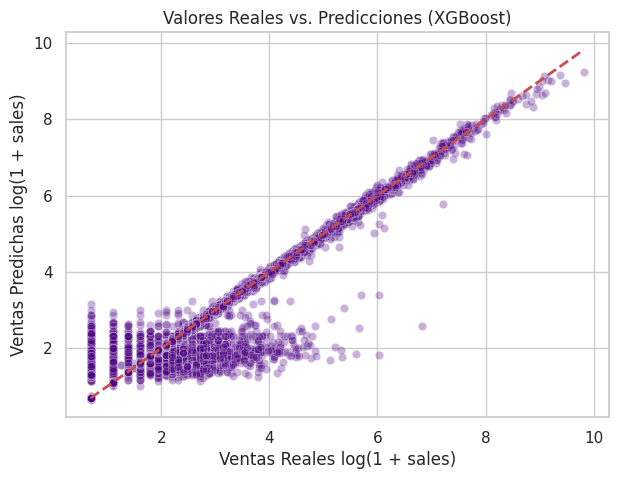

In [14]:
best_model = modelos["XGBoost"]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.3, color='indigo')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Valores Reales vs. Predicciones (XGBoost)')
plt.xlabel('Ventas Reales log(1 + sales)')
plt.ylabel('Ventas Predichas log(1 + sales)')
plt.show()

In [22]:
import joblib
import numpy as np
import pandas as pd


def predecir_ventas_nuevo_producto(
    precio, rating, comentarios, leve_1_category_id=226
):
    """Calcula las ventas estimadas de un nuevo producto en la plataforma Temu.

    """
    log_price = np.log1p(precio)
    log_comments = np.log1p(comentarios)
    price_per_rating = precio / (rating + 0.1)
    engagement_ratio = log_comments / (np.log1p(10) + 0.1)

    # DataFrame de entrada con las EXACTAS 6 características con las que fue entrenado el modelo
    input_data = pd.DataFrame(
        [
            {
                'log_price': log_price,
                'goods_score': rating,
                'log_comments': log_comments,
                'price_per_rating': price_per_rating,
                'engagement_ratio': engagement_ratio,
                'leve_1_category_id': leve_1_category_id,  # <-- Columna requerida por el modelo
            }
        ]
    )

    # Cargar modelo entrenado y realizar la predicción
    model = joblib.load('modelo_xgb_temu.pkl')
    log_sales_pred = model.predict(input_data)[0]

    # Aplicar expm1 para revertir la transformación logarítmica np.log1p
    sales_pred = np.expm1(log_sales_pred)

    return round(sales_pred)


# --- Ejemplo de uso ---
ventas_estimadas = predecir_ventas_nuevo_producto(
    precio=12.50, rating=4.7, comentarios=150, leve_1_category_id=226
)

print(f'Ventas estimadas proyectadas: {ventas_estimadas} unidades')

Ventas estimadas proyectadas: 10 unidades
